In [ ]:
from tensorflow.keras.models import load_model
from tensorflow.keras.preprocessing import image
import numpy as np
import cv2
import matplotlib.pyplot as plt

In [17]:
# Install gdown if you need to download from Google Drive
!pip install gdown

# Google Drive file ID for handwritten_character_model.h5 (REPLACE THIS WITH YOUR ACTUAL FILE ID)
# Example: '1abcdeFgHIJKLMnOPQrstUVWXYZ1234567890'
FILE_ID = 'YOUR_GOOGLE_DRIVE_FILE_ID'

# Output file name
OUTPUT_FILE = 'handwritten_character_model.h5'

# Download the file from Google Drive
!gdown --id {FILE_ID} -O {OUTPUT_FILE}

# Now try to load the model again
from tensorflow.keras.models import load_model
model = load_model(OUTPUT_FILE)

print("Model Loaded Successfully!")

/usr/local/lib/python3.12/dist-packages/gdown/__main__.py:139: FutureWarning: Option `--id` was deprecated in version 4.3.1 and will be removed in 5.0. You don't need to pass it anymore to use a file ID.
  warnings.warn(
Failed to retrieve file url:

	Cannot retrieve the public link of the file. You may need to change
	the permission to 'Anyone with the link', or have had many accesses.
	Check FAQ in https://github.com/wkentaro/gdown?tab=readme-ov-file#faq.

You may still be able to access the file from the browser:

	https://drive.google.com/uc?id=YOUR_GOOGLE_DRIVE_FILE_ID

but Gdown can't. Please check connections and permissions.


Model Loaded Successfully!


In [ ]:
import os

file_path = "handwritten_character_model.h5"

if os.path.exists(file_path):
    file_size = os.path.getsize(file_path)
    print(f"File '{file_path}' exists. Size: {file_size} bytes.")
else:
    print(f"File '{file_path}' does not exist.")

File 'handwritten_character_model.h5' exists. Size: 2741696 bytes.


In [ ]:
import os

digit_image_path = "Digit.png.jpeg"

if os.path.exists(digit_image_path):
    digit_file_size = os.path.getsize(digit_image_path)
    print(f"File '{digit_image_path}' exists. Size: {digit_file_size} bytes.")
else:
    print(f"File '{digit_image_path}' does not exist. Please ensure 'Digit.png.jpeg' is in the same directory as the notebook or provide the full path.")

File 'Digit.png.jpeg' exists. Size: 5030 bytes.


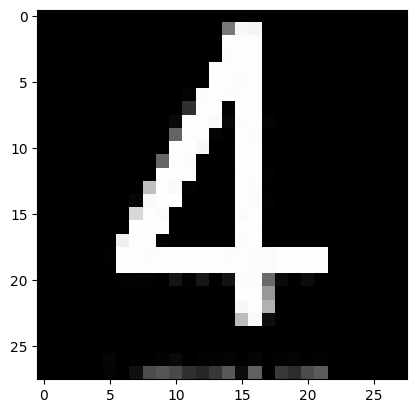

In [ ]:
img = cv2.imread("Digit.png.jpeg", cv2.IMREAD_GRAYSCALE)

img = cv2.resize(img, (28, 28))

# Color invert
img = 255 - img

# Normalize
img = img / 255.0

plt.imshow(img, cmap='gray')
plt.show()

img = img.reshape(1, 28, 28, 1)

In [18]:
from tensorflow.keras.models import load_model

# Ensure the model is loaded before prediction
# This assumes 'handwritten_character_model.h5' is available in the current directory
model = load_model('handwritten_character_model.h5')

prediction = model.predict(img)

predicted_digit = np.argmax(prediction)
confidence = np.max(prediction) * 100

print("Predicted Digit:", predicted_digit)
print("Confidence:", confidence, "%")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 206ms/step
Predicted Digit: 4
Confidence: 99.95733 %
